In [2]:
!pip install fastai ddgs

In [1]:
from fastai.vision.all import *
from ddgs import DDGS
from fastcore.all import *

def search_images(keywords, max_images=200):
    with DDGS() as ddgs:
        results = list(ddgs.images(keywords, max_results=max_images))
    return L(results).itemgot('image')

In [2]:
urls = search_images('apple fruit photos', max_images=1)
print(urls[0])

https://images.pexels.com/photos/8208/pexels-photo.jpg?cs=srgb&dl=apple-fruit-healthy-8208.jpg&fm=jpg


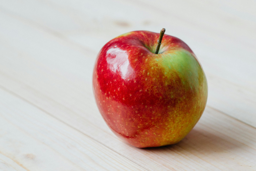

In [3]:
from fastdownload import download_url
dest = 'apple.jpg'
download_url(urls[0], 'apple.jpg', show_progress=False)

from fastai.vision.all import *
im = PILImage.create(dest)
im.to_thumb(256,256)

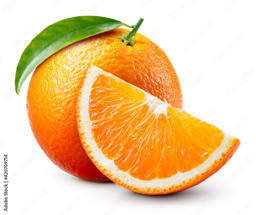

In [4]:
download_url(search_images('orange fruit photos', max_images=1)[0], 'orange.jpg', show_progress=False)
Image.open('orange.jpg').to_thumb(256,256)

In [15]:
searches = 'apple fruit photos', 'orange fruit photos'
path = Path('its_apples_and_oranges')

for o in searches:
    dest = path/o.split()[0]
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photos', max_images=200))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

In [16]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

1

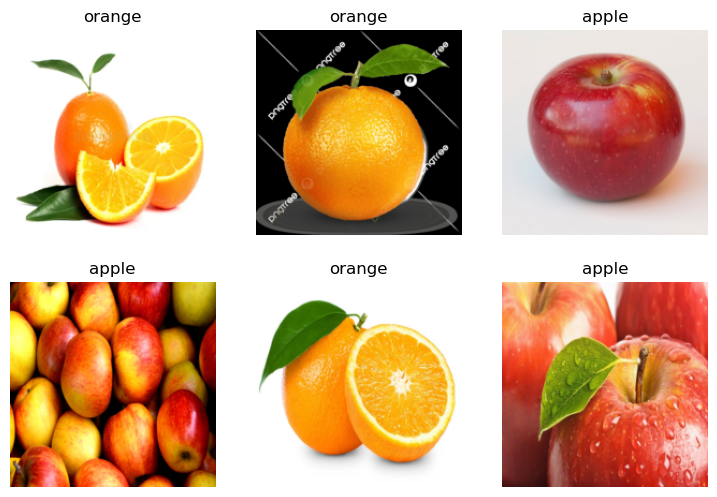

In [17]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

In [19]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.199595,0.394316,0.208333,00:05


epoch,train_loss,valid_loss,error_rate,time
0,0.305609,0.153594,0.041667,00:05
1,0.171778,0.030764,0.000000,00:05
2,0.121342,0.008454,0.000000,00:05


In [22]:
import random
files = os.listdir('its_apples_and_oranges/apple')
random_file = random.choice(files)
test_img = PILImage.create(f'its_apples_and_oranges/apple/{random_file}')
is_what, _, probs = learn.predict(test_img)
test_img.to_thumb(256,256)
print(f"This is a: {is_what}")
print(f"Probability apple: {probs[0]:.4f}")
print(f"Probability orange: {probs[1]:.4f}")

/opt/anaconda3/lib/python3.13/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


This is a: apple
Probability apple: 1.0000
Probability orange: 0.0000


In [24]:
import random
files = os.listdir('its_apples_and_oranges/orange')
random_file = random.choice(files)
test_img = PILImage.create(f'its_apples_and_oranges/orange/{random_file}')
is_what, _, probs = learn.predict(test_img)
test_img.to_thumb(256,256)
print(f"This is a: {is_what}")
print(f"Probability apple: {probs[0]:.4f}")
print(f"Probability orange: {probs[1]:.4f}")

This is a: orange
Probability apple: 0.0001
Probability orange: 0.9999


In [25]:
learn.export('apples_oranges.pkl')